<a href="https://colab.research.google.com/github/frankodzia/ai-course-gp/blob/main/Lekcja_35.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GRA KAMIEŃ-PAPIER-NOŻYCE LIVE

Część I.

1. Import bibliotek

In [1]:
# standardowe biblioteki
import os, sys, time, glob, random, base64, shutil, pathlib, io, json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

# Colab wyświetlanie
from IPython.display import Javascript, display, Audio, Image as DImage
from google.colab.output import eval_js

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from tensorflow.keras.models import load_model
print("TF:", tf.__version__)


TF: 2.20.0


2. Konfiguracja środowiska [ROBIMY NA ZAJĘCIACH]

In [22]:
# Skonfiguruj środowisko projektu [TO DO]

BASE_DIR = "/content/project_kpn"
RAW_DIR = BASE_DIR + "/raw"
DATA_DIR = BASE_DIR + "/data"

CATEGORIES = ["kamień", "papier", "nożyce"]

IMG_SIZE = (224,224)
TRAIN_RATIO = 0.8

for category in CATEGORIES:
  os.makedirs(os.path.join(RAW_DIR, category), exist_ok=True)

print(CATEGORIES)
print(RAW_DIR)

['kamień', 'papier', 'nożyce']
/content/project_kpn/raw


3. Funkcja zbierania danych (wykorzystanie Javascript)

In [21]:
# Kamerka z JavaScript: robienie wielu zdjęć do wybranej kategorii

def zbierz_proby(kategoria, ile_min=20, jakosc=0.9, lustrzane=True):
    # proste GUI w JS: przycisk "Zrób zdjęcie" i "Zakończ"
    target = os.path.join(RAW_DIR, kategoria)
    os.makedirs(target, exist_ok=True)

    js = Javascript('''
      async function sesja(nMin, q) {
        const div = document.createElement('div');
        const btn = document.createElement('button');
        btn.textContent = 'Zrób zdjęcie';
        btn.style.fontSize = '16px';
        btn.style.marginRight = '8px';
        const done = document.createElement('button');
        done.textContent = 'Zakończ';
        done.disabled = true;
        const info = document.createElement('span');
        info.style.marginLeft = '10px';
        info.textContent = '0 / ' + nMin;

        div.appendChild(btn);
        div.appendChild(done);
        div.appendChild(info);

        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.maxWidth = '480px';
        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        const images = [];
        btn.onclick = () => {
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          images.push(canvas.toDataURL('image/jpeg', q));
          info.textContent = images.length + ' / ' + nMin;
          if (images.length >= nMin) done.disabled = false;
        };

        await new Promise(resolve => done.onclick = resolve);
        stream.getTracks().forEach(t => t.stop());
        div.remove();
        return images;
      }
    ''')
    display(js)
    data_urls = eval_js(f"sesja({ile_min}, {jakosc})")


    zapisane = 0
    for i, d in enumerate(data_urls):
        raw = base64.b64decode(d.split(',')[1])
        fname = os.path.join(target, f"{kategoria}_{int(time.time()*1000)}_{i:03d}.jpg")
        with open(fname, 'wb') as f:
            f.write(raw)
        zapisane += 1

        if lustrzane:
            img = Image.open(io.BytesIO(raw)).convert('RGB')
            img = ImageOps.mirror(img)
            fname2 = os.path.join(target, f"{kategoria}_{int(time.time()*1000)}_{i:03d}_m.jpg")
            img.save(fname2, "JPEG", quality=int(jakosc*100))
            zapisane += 1

    print("Zapisano:", zapisane, "plików do", target)




4. Zbieranie danych do modelu [ROBIMY NA ZAJĘCIACH]

In [17]:
# Dla każdej klasy wywołaj funkcję do zbierania danych [TO DO]
print(CATEGORIES[0])
zbierz_proby(CATEGORIES[0], ile_min=50)

kamień


<IPython.core.display.Javascript object>

MessageError: NotFoundError: Requested device not found

In [18]:
print(CATEGORIES[1])
zbierz_proby(CATEGORIES[1], ile_min=50)

papier


<IPython.core.display.Javascript object>

MessageError: NotFoundError: Requested device not found

In [19]:
print(CATEGORIES[2])
zbierz_proby(CATEGORIES[2], ile_min=50)

nożyce


<IPython.core.display.Javascript object>

MessageError: NotFoundError: Requested device not found

In [13]:
import shutil
from google.colab import files

shutil.make_archive("/content/raw_data_20", "zip", RAW_DIR)

files.download("/content/raw_data20.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5. Podział danych

In [23]:
# Podział na train/test - kopiowanie obrazów do konkretnych folderów

def podziel_train_test():
    if os.path.exists(DATA_DIR):
        shutil.rmtree(DATA_DIR)
    for split in ["train", "test"]:
        for k in CATEGORIES:
            os.makedirs(os.path.join(DATA_DIR, split, k), exist_ok=True)

    for k in CATEGORIES:
        pliki = glob.glob(os.path.join(RAW_DIR, k, "*"))
        pliki = [p for p in pliki if os.path.isfile(p)]
        random.shuffle(pliki)
        n = len(pliki)
        n_train = int(n * TRAIN_RATIO)
        train_files = pliki[:n_train]
        test_files  = pliki[n_train:]
        for src in train_files:
            shutil.copy2(src, os.path.join(DATA_DIR, "train", k, os.path.basename(src)))
        for src in test_files:
            shutil.copy2(src, os.path.join(DATA_DIR, "test", k, os.path.basename(src)))
    print("Dane w", DATA_DIR)




In [24]:
# Wywołaj funkcję podziału danych [TO DO]
podziel_train_test()

Dane w /content/project_kpn/data


6. Wczytanie danych i trening modelu [ROBIMY NA ZAJĘCIACH]

In [25]:
# Funkcje wczytania danych i budowy modelu
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def wczytaj_dane():
    train_ds = image_dataset_from_directory(
        os.path.join(DATA_DIR, "train"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=True
    )
    test_ds = image_dataset_from_directory(
        os.path.join(DATA_DIR, "test"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=False
    )
    return train_ds.prefetch(AUTOTUNE), test_ds.prefetch(AUTOTUNE), train_ds.class_names





In [26]:
# Trenujemy model [TO DO]

def build_model(n_classes):
  input_layer = layers.Input(shape=IMG_SIZE+(3,))

  x = layers.RandomFlip("horizontal")(input_layer)
  x = layers.RandomRotation(0.1)(x)
  x = layers.RandomZoom(0.1)(x)
  x = mnv2_preprocess(x)

  base_model = MobileNetV2(include_top=False, input_tensor=x, weights="imagenet", pooling = "avg")
  base_model.trainable = False

  x = layers.Dropout(0.1)(base_model.output)
  output_layer = layers.Dense(n_classes, activation="softmax")(x)

  model = models.Model(
      input_layer,
      output_layer,
  )

  model.compile(optimizer="adam",
                loss="categorical_crossentropy",
                metrics=["accuracy"]
  )
  return model

Found 97 files belonging to 3 classes.
Found 25 files belonging to 3 classes.
class_names: ['kamień', 'nożyce', 'papier']


/tmp/ipykernel_1428/3236515004.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, input_tensor=x, weights="imagenet", pooling = "avg")


Epoch 1/6
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 601ms/step - accuracy: 0.4227 - loss: 1.2142 - val_accuracy: 0.3200 - val_loss: 1.1122
Epoch 2/6
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4227 - loss: 1.1143 - val_accuracy: 0.4000 - val_loss: 0.9833
Epoch 3/6
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.4948 - loss: 0.9324 - val_accuracy: 0.6400 - val_loss: 0.7702
Epoch 4/6
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.7010 - loss: 0.7834 - val_accuracy: 0.6800 - val_loss: 0.7138
Epoch 5/6
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.7113 - loss: 0.7430 - val_accuracy: 0.7600 - val_loss: 0.6704
Epoch 6/6
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8041 - loss: 0.6327 - val_accuracy: 0.8400 - val_loss: 0.5638
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8400 - loss: 0.5638
Test acc: 0.8399999737739563


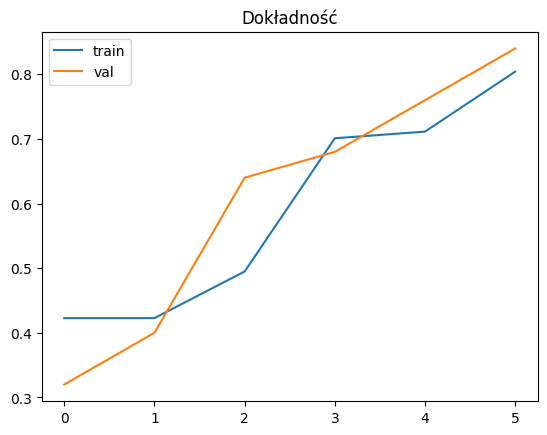

In [29]:
train_ds, test_ds, class_names = wczytaj_dane()
print("class_names:", class_names)

model = build_model(len(class_names))
hist = model.fit(train_ds, validation_data=test_ds, epochs=6)
loss, acc = model.evaluate(test_ds)
print("Test acc:", acc)

plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='val')
plt.legend(); plt.title("Dokładność"); plt.show()


# WAZNE! Możemy zapisać model na kolejne zajęcia - jesli tego nie zrobimy będzie trzeba od nowa go trenować
model.save(BASE_DIR + "/model.keras")
with open(BASE_DIR + "/class_names.txt", "w") as f:
    f.write("\n".join(class_names))

7. Predykcja LIVE z kamerki

Funkcja kamerki

In [27]:
# Predykcja z kamerki


def take_photo(nazwa="foto.jpg", jakosc=0.9):
    js = Javascript('''
      async function f(q) {
        const div = document.createElement('div');
        const b = document.createElement('button');
        b.textContent = 'Zrób zdjęcie';
        b.style.fontSize = '16px';
        b.style.marginBottom = '8px';
        div.appendChild(b);

        const video = document.createElement('video');
        video.style.display='block';
        video.style.maxWidth='480px';
        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise(resolve => b.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(t => t.stop());
        div.remove();
        return canvas.toDataURL('image/jpeg', q);
      }
    ''')
    display(js)
    data = eval_js(f"f({jakosc})")
    raw = base64.b64decode(data.split(',')[1])
    with open(nazwa, 'wb') as f:
        f.write(raw)
    return nazwa

def przygotowanie(path, rozmiar=IMG_SIZE, mirror=False):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    m = min(w, h)
    img = img.crop(((w-m)//2, (h-m)//2, (w+m)//2, (h+m)//2)).resize(rozmiar)
    if mirror:
        img = ImageOps.mirror(img)
    x = np.asarray(img).astype("float32")
    x = np.expand_dims(x, 0)  # (1,H,W,3) – preprocess jest w MODEL-U
    return x






Funkcja kamerka + klasyfikacja

In [ ]:
# Funkcja TOP3 [TO DO]


In [ ]:
# Wywołanie funkcji [TO DO]
